# 5. RQ3 - Modellvergleich: Wer überlebt die Titanic?

Vergleich verschiedener Klassifikatoren (Logistic Regression, Random Forest, KNN)

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
sns.set_style('whitegrid')

In [8]:
df = pd.read_csv('../data/processed/titanic_model_ready.csv')
print(f'Shape: {df.shape}')
print(f'Target: {df["Survived"].value_counts().to_dict()}')

Shape: (891, 13)
Target: {0: 549, 1: 342}


In [9]:
y = df['Survived']
X = df.drop(['Survived'], axis=1)
if 'PassengerId' in X.columns:
    X = X.drop(['PassengerId'], axis=1)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f'Train: {X_train.shape}, Test: {X_test.shape}')

Train: (712, 12), Test: (179, 12)


In [10]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
    'KNN': KNeighborsClassifier(n_neighbors=5)
}
trained = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    trained[name] = model
    print(f'{name}: trained')

Logistic Regression: trained
Random Forest: trained
KNN: trained


In [11]:
results = []
for name, model in trained.items():
    y_pred = model.predict(X_test)
    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred, zero_division=0),
        'Recall': recall_score(y_test, y_pred, zero_division=0),
        'F1': f1_score(y_test, y_pred, zero_division=0)
    })
results_df = pd.DataFrame(results)
print(results_df.round(4))

                 Model  Accuracy  Precision  Recall      F1
0  Logistic Regression    0.8380     0.8125  0.7536  0.7820
1        Random Forest    0.8268     0.8065  0.7246  0.7634
2                  KNN    0.6816     0.6034  0.5072  0.5512


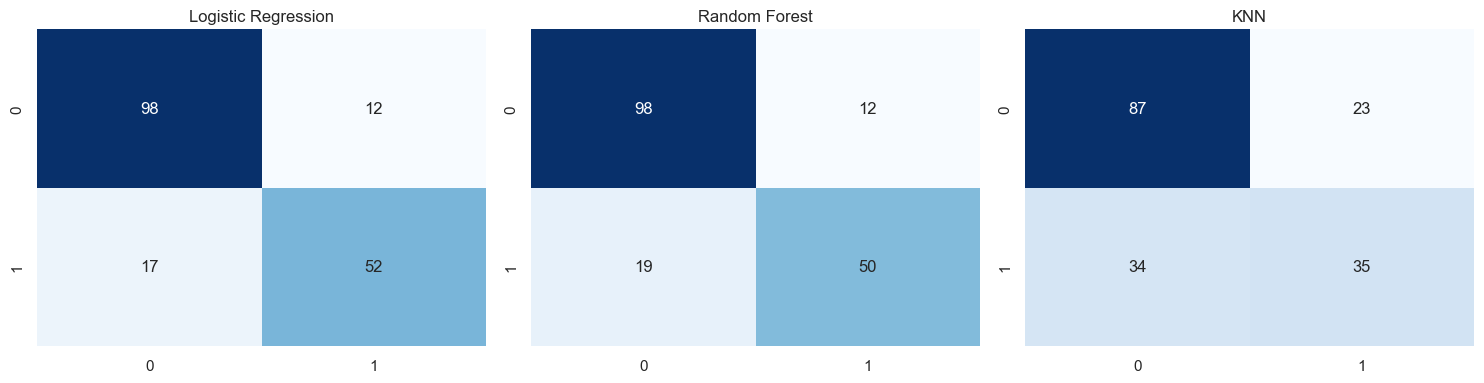

In [12]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
for idx, (name, model) in enumerate(trained.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx], cbar=False)
    axes[idx].set_title(name)
plt.tight_layout()
plt.show()